In [1]:
import matplotlib.pyplot as plt
import matplotlib
import random
import numpy as np


In [5]:
speed_FK = np.load("speed_FK_500_s=05.npy")
w_FK = np.load("w_FK_500_s=05.npy")
speed_BD = np.load("speed_BD_500_s=05,q=0.npy")
w_BD = np.load("w_BD_500_s=05,q=0.npy")
speed_DB = np.load("speed_DB_500_s=05,q=0.npy")
w_DB = np.load("w_DB_500_s=05,q=0.npy")


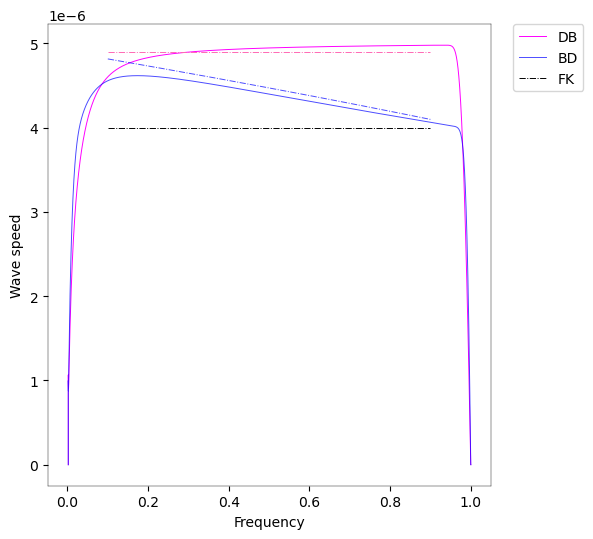

In [6]:
plt.figure(figsize=(6, 5.5))  # Keep square size

# Plot DB and BD
plt.plot(w_DB, speed_DB, c="magenta", label="DB", linewidth=0.7)
plt.plot(w_BD, speed_BD, c="b", label="BD", alpha=0.7, linewidth=0.7)

# Velocity functions
v = []
u = []
k = []

K = 500  # Number of islands
D = 1 / (2*(K ** 2))
s = 0.5
q = 0

def velocity(phi):
    v = 2 * np.sqrt(D * (s - q) *( (1 + s)- s*phi))/ K
    u =2 * np.sqrt(D * (s - q) *( (1 + s)- q*phi))/ K
    k = 2 * np.sqrt(D * (s - q)) / K
    return v, u, k

phis = np.linspace(0.1, 0.9, 1000)

for phi in phis:
    v.append(velocity(phi)[0])
    u.append(velocity(phi)[1])
    k.append(velocity(phi)[2] )

plt.plot(phis, v, c="b", linestyle="-.", alpha=0.7, linewidth=0.7)
plt.plot(phis, u, c="hotpink", linestyle="-.", linewidth=0.7)
plt.plot(phis, k, c="black", linestyle="-.", linewidth=0.7, label = "FK")

# Add space on the right for legend
plt.subplots_adjust(right=0.75)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Axis styling
plt.xlabel('Frequency', fontsize=10, fontweight="ultralight")
plt.ylabel('Wave speed', fontsize=10, fontweight="ultralight")
plt.xticks(fontsize=10, fontweight='light')
plt.yticks(fontsize=10, fontweight='light')
# plt.ylim(0, 1e-6)

# Spines
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.3)

plt.tight_layout()

# Save if needed
# plt.savefig("2.png", dpi=1000, bbox_inches="tight")

plt.show()
